In [1]:
import pandas as pd
pd.set_option('max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
import plotly.express as px
sns.set()

%matplotlib inline 


In [2]:
df = pd.read_csv('data/allegations_202007271729.csv')
df.head().T

,0,1,2,3,4
unique_mos_id,10004,10007,10007,10007,10009
first_name,Jonathan,John,John,John,Noemi
last_name,Ruiz,Sears,Sears,Sears,Sierra
command_now,078 PCT,078 PCT,078 PCT,078 PCT,078 PCT
shield_no,8409,5952,5952,5952,24058
complaint_id,42835,24601,24601,26146,40253
month_received,7,11,11,7,8
year_received,2019,2011,2011,2012,2018
month_closed,5,8,8,9,2
year_closed,2020,2012,2012,2013,2019


In [3]:
df.isna().sum()

unique_mos_id                  0
first_name                     0
last_name                      0
command_now                    0
shield_no                      0
complaint_id                   0
month_received                 0
year_received                  0
month_closed                   0
year_closed                    0
command_at_incident         1544
rank_abbrev_incident           0
rank_abbrev_now                0
rank_now                       0
rank_incident                  0
mos_ethnicity                  0
mos_gender                     0
mos_age_incident               0
complainant_ethnicity       4464
complainant_gender          4195
complainant_age_incident    4812
fado_type                      0
allegation                     1
precinct                      24
contact_reason               199
outcome_description           56
board_disposition              0
dtype: int64

In [3]:
df['precinct'] = df['precinct'].fillna(-999)

In [4]:
# add boroughs category

boroughs = {'Manhattan':[1, 5, 6, 7, 9, 10, 13, 17, 19, 20, 23, 24, 25, 26, 28, 30, 32, 33, 34],
           'Bronx':[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52],
           'Brooklyn':[60, 61, 62, 63, 66, 67, 68, 69, 70, 71, 72, 73, 75, 76, 77, 78, 79, 81, 83, 84, 88, 90, 94],
           'Queens':[100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115],
           'Staten Island':[120, 121, 122, 123]}
d = {}
for key, value in boroughs.items():
    for num in value:
        d[num] = key
            
        
df['Boroughs'] = df.precinct.astype(int).map(d)
df.head()

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,command_at_incident,rank_abbrev_incident,rank_abbrev_now,rank_now,rank_incident,mos_ethnicity,mos_gender,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition,Boroughs
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,078 PCT,POM,POM,Police Officer,Police Officer,Hispanic,M,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions),Brooklyn
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,PBBS,POM,POM,Police Officer,Police Officer,White,M,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Brooklyn
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,PBBS,POM,POM,Police Officer,Police Officer,White,M,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Brooklyn
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,PBBS,POM,POM,Police Officer,Police Officer,White,M,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges),Brooklyn
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,078 PCT,POF,POF,Police Officer,Police Officer,Hispanic,F,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A),Brooklyn


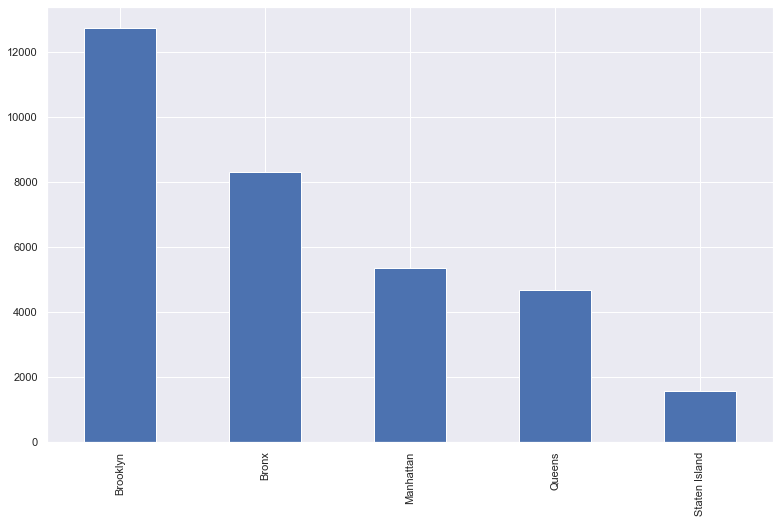

In [6]:
c = df['Boroughs'].value_counts()
c.plot(kind='bar', figsize=(13, 8))

In [12]:
print(c)

Brooklyn         12755
Bronx             8329
Manhattan         5359
Queens            4676
Staten Island     1560
Name: Boroughs, dtype: int64


In [5]:
#zipcode column

zipcode = {'10013':[1, 5], '10002':[7], '10014':[6], '10003':[9], '10011':[10], '10022':[17], 
           '10065':[19], '10024': [20], '10029': [23], '10025':[24], '10035':[25], 
           '10027': [26, 28], '10031':[30], '10030':[32], '10032':[33], '10033':[34],
          '10454':[40], '10459':[41], '10451':[42], '10473':[43], '10452':[44], '10465':[45],
          '10457':[46, 48], '10466':[47], '10461':[49], '10463':[50], '10467':[52],
          '11224':[60], '11223':[61], '11214':[62], '11210':[63], '11204':[66], '11226':[67],
          '11220':[68], '11236':[69], '11230':[70], '11225':[71], '11232':[72], '11212':[73],
          '11208':[75], '11231':[76], '11213':[77], '11217':[78], '11216':[79], '11221':[81],
          '11237':[83], '11201':[84], '11205':[88], '11211':[90], '11222':[94], '11693':[100],
          '11691':[101], '11418':[102], '11432':[103], '11385':[104], '11428':[105],
           '11417':[106], '11365':[107], '11101':[108], '11354':[109], '11373':[110],
          '11361':[111], '11375':[112], '11434':[113], '11103':[114], '11372':[115],
          '10301':[120], '10314': [121], '10306':[122], '10307':[123]}

d = {}
for key, value in zipcode.items():
    for num in value:
        d[num] = key

df['zipcode'] = df.precinct.astype(int).map(d)
df.head()



,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,command_at_incident,rank_abbrev_incident,rank_abbrev_now,rank_now,rank_incident,mos_ethnicity,mos_gender,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition,Boroughs,zipcode
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,078 PCT,POM,POM,Police Officer,Police Officer,Hispanic,M,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions),Brooklyn,11217
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,PBBS,POM,POM,Police Officer,Police Officer,White,M,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Brooklyn,11226
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,PBBS,POM,POM,Police Officer,Police Officer,White,M,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges),Brooklyn,11226
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,PBBS,POM,POM,Police Officer,Police Officer,White,M,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges),Brooklyn,11226
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,078 PCT,POF,POF,Police Officer,Police Officer,Hispanic,F,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A),Brooklyn,11226


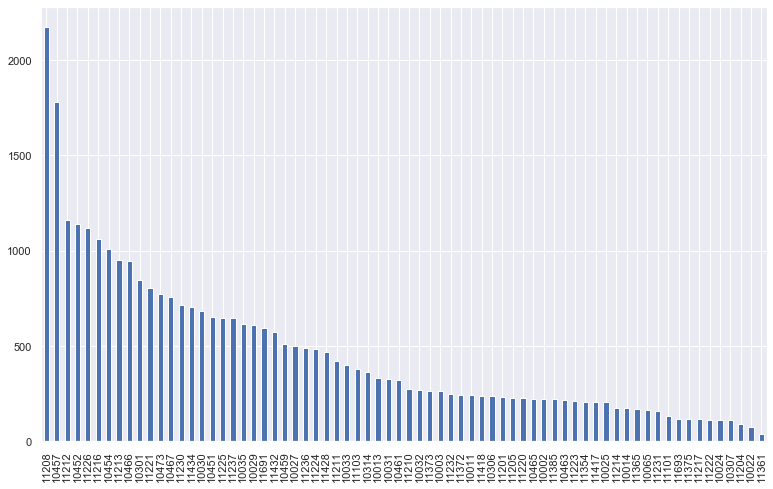

In [8]:
d = df['zipcode'].value_counts()
d.plot(kind='bar', figsize=(13, 8))

In [28]:
datas = {'Boroughs':['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island'],
        'numOfComplaints' : [12755, 5359, 4676, 8329, 1560]}
df1 = pd.DataFrame(datas)
df1

,Boroughs,numOfComplaints
0,Brooklyn,12755
1,Manhattan,5359
2,Queens,4676
3,Bronx,8329
4,Staten Island,1560


In [15]:
gb = df.groupby(['year_received'])['Counts'].transform('count')
new_df = pd.DataFrame(gb)
new_df = new_df.reset_index()

new_df.head()

,index,Counts
0,0,1642
1,1,1896
2,2,1896
3,3,1841
4,4,2281


In [18]:
new_df['year_received'] = df['year_received'].values
new_df['Boroughs'] = df['Boroughs'].values

new_df.head()

,index,Counts,year_received,Boroughs
0,0,1642,2019,Brooklyn
1,1,1896,2011,Brooklyn
2,2,1896,2011,Brooklyn
3,3,1841,2012,Brooklyn
4,4,2281,2018,Brooklyn


In [23]:
c1 = new_df['Boroughs'] == 'Manhattan'

new_df[c1]

,index,Counts,year_received,Boroughs
91,91,2312,2015,Manhattan
92,92,2312,2015,Manhattan
93,93,2312,2015,Manhattan
94,94,2312,2015,Manhattan
95,95,2312,2015,Manhattan
...,...,...,...,...
33263,33263,571,2002,Manhattan
33264,33264,571,2002,Manhattan
33265,33265,1654,2006,Manhattan
33266,33266,1654,2006,Manhattan


In [28]:
groupby_cols = ['year_received', 'Boroughs']
gb1 = df.groupby(groupby_cols)['Counts'].count()

final = pd.DataFrame(gb1)
final = final.reset_index()

final.head()

,year_received,Boroughs,Counts
0,1985,Brooklyn,7
1,1986,Brooklyn,17
2,1987,Bronx,1
3,1987,Brooklyn,16
4,1987,Manhattan,2


In [30]:
# This is going to be the final dataset we are going to use
